# Direction V: Robust external validation + cluster-aware + quinolone-aware extension

Phát triển tiếp từ **Direction U**.

**Vấn đề sau Direction U:** kết quả external multi-drug đã tốt, nhưng vẫn cần kiểm tra chắc hơn:

1. Stratified random split có thể bị ảnh hưởng bởi genome quá giống nhau.
2. Group-aware metadata có thể bị skip nếu metadata không đủ.
3. CIP/NAL thuộc quinolone/fluoroquinolone; cơ chế kháng thường liên quan mutation như `gyrA/parC`, nên feature presence/absence có thể giải thích chưa tốt.
4. Cần negative control và bảng kết luận tự động để viết báo cáo.

**Làm thêm:**

- Reuse output/cache từ Direction U nếu có.
- Tạo **cluster-aware split bằng Jaccard similarity** giữa genome annotation features, không phụ thuộc metadata.
- Thêm **keyword/proxy AMR features**, đặc biệt cho CIP/NAL.
- Hỗ trợ optional file **AMRFinderPlus** nếu bạn có bảng kết quả riêng.
- So sánh `base_annotation` vs `base_plus_keyword_proxy`.


In [1]:
# =========================
# 0. Mount Drive, nếu chạy Colab
# =========================
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Không chạy trên Colab hoặc không cần mount Drive:', repr(e)[:120])


Mounted at /content/drive


In [2]:
# =========================
# 1. Imports + config
# =========================

import os
import re
import json
import time
import math
import shutil
import warnings
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

import requests
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

PROJECT_NAME = 'salmonella_direction_V_robust_external_validation'
BASE_DIR = Path('/content') / PROJECT_NAME
OUTPUT_DIR = BASE_DIR / 'outputs'
REPO_DIR = BASE_DIR / 'AMRMetadataReview_2021'

# Reuse Direction U nếu bạn vừa chạy U trong cùng Colab.
REUSE_DIRECTION_U_OUTPUTS = True
U_BASE_DIR = Path('/content/salmonella_direction_U_external_multidrug')
U_OUTPUT_DIR = U_BASE_DIR / 'outputs'
U_CACHE_DIR = U_BASE_DIR / 'cache_bvbrc_features'

CACHE_DIR = U_CACHE_DIR if (REUSE_DIRECTION_U_OUTPUTS and U_CACHE_DIR.exists()) else (BASE_DIR / 'cache_bvbrc_features')

for d in [BASE_DIR, OUTPUT_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_DRUGS = [
    {'drug_code': 'TET', 'contains': 'tetracycline', 'drug_class': 'tetracycline'},
    {'drug_code': 'CIP', 'contains': 'ciprofloxacin', 'drug_class': 'fluoroquinolone'},
    {'drug_code': 'STR', 'contains': 'streptomycin', 'drug_class': 'aminoglycoside'},
    {'drug_code': 'GEN', 'contains': 'gentamicin', 'drug_class': 'aminoglycoside'},
    {'drug_code': 'NAL', 'contains': 'nalidixic acid', 'drug_class': 'quinolone'},
]

# Chạy nhanh: giảm N_REPEATS hoặc TARGET_DRUGS.
N_PER_CLASS = 250
N_REPEATS = 3
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.25

K_FEATURES_LIST = [100, 200, 500]
MODEL_NAMES = ['lr_balanced', 'xgb_weighted'] if HAS_XGB else ['lr_balanced', 'rf_balanced']

RUN_CLUSTER_AWARE = True
CLUSTER_THRESHOLDS = [0.995, 0.98]
RUN_NEGATIVE_CONTROL = True

# Optional AMRFinderPlus result. Nếu có, upload file TSV rồi sửa path ở đây.
USE_OPTIONAL_AMRFINDERPLUS = False
AMRFINDER_PATH = BASE_DIR / 'optional_amrfinderplus_results.tsv'

# BV-BRC API
API_BASE = 'https://www.bv-brc.org/api'
FEATURE_FIELDS = [
    'genome_id', 'patric_id', 'feature_id', 'feature_type',
    'gene', 'product', 'pgfam_id', 'plfam_id'
]
API_SLEEP = 0.10
API_LIMIT_PER_QUERY = 50000

print('HAS_XGB:', HAS_XGB)
print('BASE_DIR:', BASE_DIR)
print('CACHE_DIR:', CACHE_DIR)
print('Reuse Direction U outputs:', REUSE_DIRECTION_U_OUTPUTS and U_OUTPUT_DIR.exists())
print('TARGET_DRUGS:', [d['drug_code'] for d in TARGET_DRUGS])
print('N_PER_CLASS:', N_PER_CLASS, '| N_REPEATS:', N_REPEATS)
print('MODEL_NAMES:', MODEL_NAMES)


HAS_XGB: True
BASE_DIR: /content/salmonella_direction_V_robust_external_validation
CACHE_DIR: /content/salmonella_direction_V_robust_external_validation/cache_bvbrc_features
Reuse Direction U outputs: False
TARGET_DRUGS: ['TET', 'CIP', 'STR', 'GEN', 'NAL']
N_PER_CLASS: 250 | N_REPEATS: 3
MODEL_NAMES: ['lr_balanced', 'xgb_weighted']


## 1. Load AMR metadata

Nếu Direction U output đã có `model_rows` và `tokens_by_genome`, Direction V sẽ ưu tiên dùng lại. Metadata vẫn được load để fallback khi thiếu file U.


In [3]:
# =========================
# 2. Clone AMR metadata repo nếu cần
# =========================

if REUSE_DIRECTION_U_OUTPUTS and U_BASE_DIR.exists() and (U_BASE_DIR / 'AMRMetadataReview_2021').exists():
    REPO_DIR = U_BASE_DIR / 'AMRMetadataReview_2021'
    print('Dùng lại repo metadata từ Direction U:', REPO_DIR)
else:
    if not REPO_DIR.exists():
        print('Cloning BV-BRC AMR metadata repo...')
        subprocess.run(
            ['git', 'clone', '--depth', '1', 'https://github.com/BV-BRC/AMRMetadataReview_2021.git', str(REPO_DIR)],
            check=True
        )
    else:
        print('Repo đã tồn tại:', REPO_DIR)

print('Repo dir:', REPO_DIR)
print('Một số file tabular:')
for p in sorted((REPO_DIR / 'tabular').glob('*'))[:10]:
    print(' -', p.name)


Cloning BV-BRC AMR metadata repo...
Repo dir: /content/salmonella_direction_V_robust_external_validation/AMRMetadataReview_2021
Một số file tabular:
 - AMR.tbl.v4
 - README.md
 - amr.mic.filt.tab
 - amr.sir.filt.tab


In [4]:
# =========================
# 3. Đọc AMR long table và lọc Salmonella
# =========================

tabular_dir = REPO_DIR / 'tabular'
files = sorted([p for p in tabular_dir.glob('*') if p.is_file()])


def read_any_table(path):
    path = Path(path)
    df = pd.read_csv(path, sep='\t', low_memory=False)
    if df.shape[1] == 1:
        df = pd.read_csv(path, low_memory=False)
    return df


def norm_col(c):
    return re.sub(r'[^a-z0-9]+', '_', str(c).lower()).strip('_')


def find_col(df, keywords):
    for c in df.columns:
        nc = norm_col(c)
        if all(k in nc for k in keywords):
            return c
    return None


def find_col_any(df, list_of_keyword_lists):
    for kws in list_of_keyword_lists:
        c = find_col(df, kws)
        if c is not None:
            return c
    return None


def infer_columns(df):
    return {
        'genome_id': find_col_any(df, [['genome', 'id'], ['genome_id'], ['genome']]),
        'genome_name': find_col_any(df, [['genome', 'name'], ['organism', 'name'], ['organism'], ['species'], ['taxon']]),
        'antibiotic': find_col_any(df, [['antibiotic'], ['drug'], ['antimicrobial']]),
        'phenotype': find_col_any(df, [['resistant', 'phenotype'], ['phenotype'], ['sir'], ['resistance']]),
        'serovar': find_col_any(df, [['serovar'], ['serotype']]),
        'isolation_source': find_col_any(df, [['isolation', 'source'], ['source']]),
        'collection_date': find_col_any(df, [['collection', 'date'], ['date']]),
        'country': find_col_any(df, [['country']]),
        'host': find_col_any(df, [['host']]),
    }


def parse_sir_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ['r', 'resistant', 'resistance', 'non-susceptible', 'nonsusceptible']:
        return 'R'
    if s in ['s', 'susceptible', 'sensitive', 'susceptibility']:
        return 'S'
    if s in ['i', 'intermediate']:
        return 'I'
    if 'resistant' in s and 'suscept' not in s:
        return 'R'
    if 'suscept' in s or 'sensitive' in s:
        return 'S'
    if 'intermediate' in s:
        return 'I'
    return np.nan


def normalize_antibiotic_name(x):
    s = str(x).strip()
    s = re.sub(r':.*$', '', s)
    s = s.replace('_', ' ').replace('-', ' ')
    s = re.sub(r'\s+', ' ', s).strip()
    return s


ANTIBIOTIC_SYNONYMS = {
    'tetracycline': 'TET',
    'ciprofloxacin': 'CIP',
    'streptomycin': 'STR',
    'gentamicin': 'GEN',
    'nalidixic acid': 'NAL',
    'kanamycin': 'KAN',
    'ceftiofur': 'CEF',
    'sulfisoxazole': 'FIS',
    'trimethoprim sulphamethoxazole': 'SXT',
    'trimethoprim sulfamethoxazole': 'SXT',
    'trimethoprim-sulfamethoxazole': 'SXT',
    'trimethoprim/sulfamethoxazole': 'SXT',
    'ampicillin': 'AMP',
    'chloramphenicol': 'CHL',
}


def antibiotic_code(name):
    s = normalize_antibiotic_name(name).lower()
    if s in ANTIBIOTIC_SYNONYMS:
        return ANTIBIOTIC_SYNONYMS[s]
    for key, code in ANTIBIOTIC_SYNONYMS.items():
        if key in s:
            return code
    return re.sub(r'[^A-Za-z]', '', s).upper()[:3]


long_tables = []
for p in files:
    try:
        df = read_any_table(p)
        cols = infer_columns(df)
        if cols['genome_id'] and cols['antibiotic'] and cols['phenotype']:
            tmp = pd.DataFrame()
            tmp['source_file'] = p.name
            tmp['genome_id'] = df[cols['genome_id']].astype(str)
            tmp['genome_name'] = df[cols['genome_name']].astype(str) if cols['genome_name'] else ''
            tmp['antibiotic'] = df[cols['antibiotic']].map(normalize_antibiotic_name)
            tmp['drug_code'] = tmp['antibiotic'].map(antibiotic_code)
            tmp['phenotype'] = df[cols['phenotype']].map(parse_sir_value)
            for out_col in ['serovar', 'isolation_source', 'collection_date', 'country', 'host']:
                tmp[out_col] = df[cols[out_col]].astype(str) if cols.get(out_col) else ''
            long_tables.append(tmp)
            print('OK:', p.name, tmp.shape)
    except Exception as e:
        print('Skip:', p.name, repr(e)[:160])

if not long_tables:
    raise RuntimeError('Không đọc được bảng AMR nào. Kiểm tra repo/tabular.')

amr = pd.concat(long_tables, ignore_index=True)
amr = amr.dropna(subset=['genome_id', 'antibiotic', 'phenotype'])
amr = amr[amr['phenotype'].isin(['S', 'R'])].copy()

salm = amr[amr['genome_name'].str.contains('salmonella', case=False, na=False)].copy()
if len(salm) == 0:
    salm = amr[amr['source_file'].str.contains('salmonella', case=False, na=False)].copy()


def resolve_duplicate(g):
    vc = g['phenotype'].value_counts()
    keep = vc.index[0]
    row = g.iloc[0].copy()
    row['phenotype'] = keep
    row['n_duplicate_rows'] = len(g)
    row['has_conflict'] = int(g['phenotype'].nunique() > 1)
    return row

salm = (
    salm
    .groupby(['genome_id', 'drug_code'], as_index=False, group_keys=False)
    .apply(resolve_duplicate)
    .reset_index(drop=True)
)

print('AMR rows:', amr.shape)
print('Salmonella S/R unique genome-drug rows:', salm.shape)
print(salm['phenotype'].value_counts())
display(salm.head())
salm.to_csv(OUTPUT_DIR / 'direction_V_salmonella_external_long_table.csv', index=False)


OK: AMR.tbl.v4 (550802, 11)
Skip: README.md ParserError('Error tokenizing data. C error: Expected 1 fields in line 4, saw 3\n')
AMR rows: (348230, 11)
Salmonella S/R unique genome-drug rows: (39313, 13)
phenotype
S    30152
R     9161
Name: count, dtype: int64


,source_file,genome_id,genome_name,antibiotic,drug_code,phenotype,serovar,isolation_source,collection_date,country,host,n_duplicate_rows,has_conflict
0,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,amoxicillin clavulanic acid,AMO,S,,nan,,,,1,0
1,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,ampicillin,AMP,R,,nan,,,,1,0
2,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,azithromycin,AZI,S,,nan,,,,1,0
3,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,cefoxitin,CEF,R,,nan,,,,3,1
4,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,chloramphenicol,CHL,S,,nan,,,,1,0


## 2. Fetch / reuse genome annotation features

Direction V dùng token presence/absence từ `pgfam_id`, `plfam_id`, `gene`, `product`. Nếu đã có output Direction U, cell này sẽ đọc lại `tokens_by_genome` để không phải fetch API lại.


In [5]:
# =========================
# 4. Genome feature API + token functions
# =========================

def clean_feature_token(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s == '' or s in ['nan', 'none', 'hypothetical protein']:
        return None
    s = re.sub(r'[^a-z0-9_\-\.\(\)\+]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    if len(s) < 2:
        return None
    return s[:160]


def features_to_tokens(df):
    tokens = []
    for _, r in df.iterrows():
        for col, prefix in [
            ('pgfam_id', 'pgfam'),
            ('plfam_id', 'plfam'),
            ('gene', 'gene'),
            ('product', 'prod'),
        ]:
            if col in df.columns:
                tok = clean_feature_token(r.get(col))
                if tok:
                    tokens.append(f'{prefix}:{tok}')
    return sorted(set(tokens))


def fetch_features_for_genome_eq(genome_id):
    select = ','.join(FEATURE_FIELDS)
    url = f'{API_BASE}/genome_feature/?eq(genome_id,{genome_id})&select({select})&limit({API_LIMIT_PER_QUERY})'
    headers = {'Accept': 'application/json'}
    r = requests.get(url, headers=headers, timeout=90)
    if r.status_code != 200:
        raise RuntimeError(f'HTTP {r.status_code}: {r.text[:300]}')
    return r.json()


def fetch_features_for_genome(genome_id):
    safe_id = str(genome_id).replace('.', '_').replace('/', '_')
    cache_file = CACHE_DIR / f'features_{safe_id}.json'
    if cache_file.exists():
        with open(cache_file, 'r', encoding='utf-8') as f:
            return json.load(f)
    data = fetch_features_for_genome_eq(genome_id)
    with open(cache_file, 'w', encoding='utf-8') as f:
        json.dump(data, f)
    time.sleep(API_SLEEP)
    return data


def genome_features_to_token_list(genome_id):
    try:
        data = fetch_features_for_genome(genome_id)
        if isinstance(data, dict) and 'response' in data and 'docs' in data['response']:
            data = data['response']['docs']
        if not isinstance(data, list) or len(data) == 0:
            return []
        df = pd.DataFrame(data)
        return features_to_tokens(df)
    except Exception as e:
        print('Fetch failed:', genome_id, repr(e)[:180])
        return []


def fetch_tokens_for_genomes(genome_ids, progress_every=25):
    tokens_by_genome = {}
    failed = []
    genome_ids = list(dict.fromkeys([str(g) for g in genome_ids]))
    for i, gid in enumerate(genome_ids, start=1):
        if i == 1 or i % progress_every == 0:
            print(f'Fetching {i}/{len(genome_ids)}...')
        toks = genome_features_to_token_list(gid)
        tokens_by_genome[gid] = toks
        if len(toks) == 0:
            failed.append(gid)
    return tokens_by_genome, failed


def load_direction_u_tokens_if_available(drug_code):
    if not (REUSE_DIRECTION_U_OUTPUTS and U_OUTPUT_DIR.exists()):
        return None, None
    rows_path = U_OUTPUT_DIR / f'direction_U_{drug_code}_model_rows.csv'
    tokens_path = U_OUTPUT_DIR / f'direction_U_{drug_code}_tokens_by_genome.json'
    if rows_path.exists() and tokens_path.exists():
        model_df = pd.read_csv(rows_path)
        with open(tokens_path, 'r', encoding='utf-8') as f:
            tokens_by_genome = json.load(f)
        print(f'Reuse U data for {drug_code}:', model_df.shape, 'tokens:', len(tokens_by_genome))
        return model_df, tokens_by_genome
    return None, None


## 3. Quinolone-aware / AMR proxy features

Lưu ý: `base_plus_keyword_proxy` **không thay thế** mutation calling thật. Nó chỉ tạo thêm các feature tóm tắt như `proxy:has_gyr`, `proxy:has_qnr`, `proxy:has_efflux`. Nếu bạn có AMRFinderPlus, bật `USE_OPTIONAL_AMRFINDERPLUS=True` để thêm token từ bảng đó.


In [6]:
# =========================
# 5. Keyword/proxy features + optional AMRFinderPlus
# =========================

DRUG_KEYWORDS = {
    'TET': ['tet', 'tetracycline', 'efflux', 'mfs'],
    'CIP': ['ciprofloxacin', 'fluoroquinolone', 'quinolone', 'gyr', 'gyra', 'gyrb', 'parc', 'pare', 'qnr', 'aac_6', 'aac(6', 'efflux', 'acr', 'mar'],
    'NAL': ['nalidixic', 'quinolone', 'gyr', 'gyra', 'gyrb', 'parc', 'pare', 'qnr', 'efflux', 'acr', 'mar'],
    'STR': ['streptomycin', 'stra', 'strb', 'aada', 'aad', 'aminoglycoside', 'aph', 'ant'],
    'GEN': ['gentamicin', 'aminoglycoside', 'aac', 'aph', 'ant', 'aad', 'acetyltransferase', 'nucleotidyltransferase', 'phosphotransferase'],
}

GENERAL_AMR_KEYWORDS = [
    'beta_lactamase', 'betalactamase', 'resistance', 'efflux', 'transporter',
    'integron', 'integrase', 'plasmid', 'transposase', 'multidrug', 'mdt', 'acr', 'mar'
]


def token_has_keyword(token, keywords):
    t = token.lower()
    compact = re.sub(r'[^a-z0-9]+', '', t)
    for kw in keywords:
        k = kw.lower()
        kc = re.sub(r'[^a-z0-9]+', '', k)
        if k in t or (kc and kc in compact):
            return True
    return False


def add_keyword_proxy_tokens(tokens, drug_code):
    tokens = list(tokens)
    lower_join = ' '.join(tokens).lower()
    proxy = []

    # Drug-specific mechanism proxies.
    for kw in DRUG_KEYWORDS.get(drug_code, []):
        if token_has_keyword(lower_join, [kw]):
            safe = clean_feature_token(kw)
            proxy.append(f'proxy:{drug_code}:has_{safe}')

    # General AMR/mobile proxies.
    for kw in GENERAL_AMR_KEYWORDS:
        if token_has_keyword(lower_join, [kw]):
            safe = clean_feature_token(kw)
            proxy.append(f'proxy:general_amr:has_{safe}')

    # Quinolone-specific grouped proxies.
    if drug_code in ['CIP', 'NAL']:
        groups = {
            'qnr_family': ['qnr'],
            'gyrase_related': ['gyr', 'gyra', 'gyrb'],
            'topoisomerase_related': ['parc', 'pare'],
            'efflux_related': ['efflux', 'acr', 'mar'],
            'aac6_related': ['aac_6', 'aac(6'],
        }
        for group_name, kws in groups.items():
            if token_has_keyword(lower_join, kws):
                proxy.append(f'proxy:quinolone:{group_name}')

    return sorted(set(tokens + proxy))


def infer_col_by_keywords(df, keyword_options):
    cols = list(df.columns)
    norm_map = {c: norm_col(c) for c in cols}
    for kws in keyword_options:
        for c, nc in norm_map.items():
            if all(k in nc for k in kws):
                return c
    return None


def load_optional_amrfinder_tokens(path):
    path = Path(path)
    if not path.exists():
        print('Không thấy AMRFinderPlus file:', path)
        return {}
    df = pd.read_csv(path, sep='\t', low_memory=False)
    genome_col = infer_col_by_keywords(df, [['genome', 'id'], ['genome'], ['isolate'], ['sample']])
    if genome_col is None:
        raise ValueError('Không tìm thấy cột genome/sample trong AMRFinderPlus TSV.')

    token_cols = []
    for opts in [
        [['gene', 'symbol'], ['element', 'symbol'], ['gene']],
        [['element', 'name'], ['product'], ['protein']],
        [['class']],
        [['subclass']],
        [['method']],
        [['point', 'mutation'], ['mutation']],
    ]:
        c = infer_col_by_keywords(df, opts)
        if c and c not in token_cols:
            token_cols.append(c)

    out = defaultdict(list)
    for _, r in df.iterrows():
        gid = str(r[genome_col])
        for c in token_cols:
            tok = clean_feature_token(r.get(c))
            if tok:
                out[gid].append(f'amrfinder:{norm_col(c)}:{tok}')
    out = {gid: sorted(set(toks)) for gid, toks in out.items()}
    print('Loaded AMRFinderPlus tokens:', len(out), 'genomes')
    return out

amrfinder_token_map = {}
if USE_OPTIONAL_AMRFINDERPLUS:
    amrfinder_token_map = load_optional_amrfinder_tokens(AMRFINDER_PATH)


## 4. Modeling helpers

Feature selection luôn fit trên train. Threshold được tune trên validation. Test chỉ dùng một lần để report metric.


In [7]:
# =========================
# 6. Matrix, split, evaluation helpers
# =========================

def build_sparse_matrix(token_lists):
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(token_lists).astype(np.float32)
    feature_names = np.array(mlb.classes_)
    return X.tocsr(), feature_names


def safe_scores(y_true, y_pred, y_prob):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        out['auroc'] = roc_auc_score(y_true, y_prob)
    except Exception:
        out['auroc'] = np.nan
    try:
        out['auprc'] = average_precision_score(y_true, y_prob)
    except Exception:
        out['auprc'] = np.nan
    return out


def choose_threshold(y_val, prob_val):
    best = {'threshold': 0.5, 'f1': -1, 'balanced_accuracy': -1}
    for th in np.linspace(0.05, 0.95, 91):
        pred = (prob_val >= th).astype(int)
        f1 = f1_score(y_val, pred, zero_division=0)
        ba = balanced_accuracy_score(y_val, pred)
        if (f1 > best['f1']) or (f1 == best['f1'] and ba > best['balanced_accuracy']):
            best = {'threshold': float(th), 'f1': float(f1), 'balanced_accuracy': float(ba)}
    return best['threshold']


def get_model(model_name, y_train, seed):
    if model_name == 'lr_balanced':
        return LogisticRegression(
            class_weight='balanced',
            max_iter=3000,
            solver='liblinear',
            random_state=seed,
        )
    if model_name == 'rf_balanced':
        return RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=seed,
        )
    if model_name == 'xgb_weighted':
        if not HAS_XGB:
            raise RuntimeError('xgboost chưa import được.')
        pos = max(1, int(np.sum(y_train == 1)))
        neg = max(1, int(np.sum(y_train == 0)))
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            scale_pos_weight=neg / pos,
            eval_metric='logloss',
            random_state=seed,
            n_jobs=2,
        )
    raise ValueError(model_name)


def predict_proba_positive(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        z = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-z))
    return model.predict(X)


def select_top_k_chi2(X_train, y_train, k):
    k = int(min(k, X_train.shape[1]))
    scores, _ = chi2(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, posinf=np.inf, neginf=-np.inf)
    if k <= 0:
        raise ValueError('k phải > 0')
    idx = np.argpartition(-scores, kth=k-1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    return idx, scores[idx]


def get_feature_importance(model, selected_idx, feature_names):
    if hasattr(model, 'coef_'):
        imp = np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        imp = np.ones(len(selected_idx), dtype=float)
    order = np.argsort(-imp)[:30]
    rows = []
    for rank, j in enumerate(order, start=1):
        if j >= len(selected_idx):
            continue
        orig_idx = selected_idx[j]
        rows.append({
            'rank': rank,
            'feature': str(feature_names[orig_idx]),
            'importance': float(imp[j]),
        })
    return rows


def valid_class_split(y, idx_train, idx_val, idx_test):
    for idx in [idx_train, idx_val, idx_test]:
        if len(idx) == 0 or len(np.unique(y[idx])) < 2:
            return False
    return True


def make_stratified_split(y, seed):
    idx_all = np.arange(len(y))
    train_val_idx, test_idx = train_test_split(
        idx_all, test_size=TEST_SIZE, stratify=y, random_state=seed
    )
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=VAL_SIZE, stratify=y[train_val_idx], random_state=seed + 1000
    )
    return train_idx, val_idx, test_idx


def make_group_split(y, groups, seed, max_tries=50):
    idx_all = np.arange(len(y))
    groups = np.asarray(groups)
    for add in range(max_tries):
        rs = seed + add
        gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=rs)
        train_val_idx, test_idx = next(gss1.split(idx_all, y, groups=groups))
        gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=rs + 1000)
        train_idx_rel, val_idx_rel = next(gss2.split(train_val_idx, y[train_val_idx], groups=groups[train_val_idx]))
        train_idx = train_val_idx[train_idx_rel]
        val_idx = train_val_idx[val_idx_rel]
        if valid_class_split(y, train_idx, val_idx, test_idx):
            return train_idx, val_idx, test_idx
    return None, None, None


def evaluate_matrix(X, y, model_df, drug_code, feature_set, split_mode, feature_names, cluster_labels=None):
    metric_rows = []
    top_rows = []
    seeds = [RANDOM_SEED + 37 * i for i in range(N_REPEATS)]

    for repeat_id, seed in enumerate(seeds):
        if split_mode == 'stratified_random':
            train_idx, val_idx, test_idx = make_stratified_split(y, seed)
        elif split_mode.startswith('cluster_aware'):
            if cluster_labels is None or len(np.unique(cluster_labels)) < 4:
                continue
            train_idx, val_idx, test_idx = make_group_split(y, cluster_labels, seed)
            if train_idx is None:
                continue
        else:
            raise ValueError(split_mode)

        for k in K_FEATURES_LIST:
            try:
                selected_idx, selected_scores = select_top_k_chi2(X[train_idx], y[train_idx], k)
            except Exception as e:
                print('Feature selection failed:', drug_code, feature_set, split_mode, k, e)
                continue

            X_train = X[train_idx][:, selected_idx]
            X_val = X[val_idx][:, selected_idx]
            X_test = X[test_idx][:, selected_idx]

            for model_name in MODEL_NAMES:
                try:
                    model = get_model(model_name, y[train_idx], seed)
                    model.fit(X_train, y[train_idx])
                    val_prob = predict_proba_positive(model, X_val)
                    th = choose_threshold(y[val_idx], val_prob)
                    test_prob = predict_proba_positive(model, X_test)
                    test_pred = (test_prob >= th).astype(int)
                    scores = safe_scores(y[test_idx], test_pred, test_prob)

                    row = {
                        'drug_code': drug_code,
                        'feature_set': feature_set,
                        'split_mode': split_mode,
                        'repeat': repeat_id,
                        'seed': seed,
                        'model': model_name,
                        'k_features': int(min(k, X.shape[1])),
                        'threshold': th,
                        'n_train': len(train_idx),
                        'n_val': len(val_idx),
                        'n_test': len(test_idx),
                        'test_pos_rate': float(np.mean(y[test_idx])),
                    }
                    row.update(scores)
                    metric_rows.append(row)

                    for fr in get_feature_importance(model, selected_idx, feature_names):
                        fr.update({
                            'drug_code': drug_code,
                            'feature_set': feature_set,
                            'split_mode': split_mode,
                            'repeat': repeat_id,
                            'seed': seed,
                            'model': model_name,
                            'k_features': int(min(k, X.shape[1])),
                        })
                        top_rows.append(fr)
                except Exception as e:
                    print('Model failed:', drug_code, feature_set, split_mode, model_name, k, repr(e)[:180])

    return pd.DataFrame(metric_rows), pd.DataFrame(top_rows)


## 5. Cluster-aware split bằng genome similarity

Cell này tạo cluster bằng Jaccard similarity trên ma trận annotation. Ý nghĩa:

- Nếu 2 genome có annotation gần như giống nhau, đưa chúng vào cùng cluster.
- Khi split theo cluster, train/test ít bị trộn các genome quá giống nhau.
- Đây là lựa chọn thay thế khi metadata `serovar/source/country` không đủ để group-aware.


In [8]:
# =========================
# 7. Jaccard similarity clusters
# =========================

def compute_jaccard_similarity(X):
    Xb = X.astype(bool).astype(np.uint8).tocsr()
    inter = (Xb @ Xb.T).toarray().astype(np.float32)
    row_sum = np.asarray(Xb.sum(axis=1)).ravel().astype(np.float32)
    union = row_sum[:, None] + row_sum[None, :] - inter
    sim = np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)
    np.fill_diagonal(sim, 1.0)
    return sim


def make_similarity_clusters(X, threshold):
    sim = compute_jaccard_similarity(X)
    adj = sim >= threshold
    np.fill_diagonal(adj, True)
    n_components, labels = connected_components(sparse.csr_matrix(adj), directed=False, return_labels=True)
    return labels.astype(int), sim


def summarize_clusters(labels, sim, y, drug_code, threshold):
    sizes = pd.Series(labels).value_counts()
    # Near-duplicate pairs excluding diagonal.
    upper = np.triu(sim, k=1)
    near_pairs = int(np.sum(upper >= threshold))
    very_near_pairs = int(np.sum(upper >= 0.995))
    return {
        'drug_code': drug_code,
        'threshold': threshold,
        'n_samples': int(len(labels)),
        'n_clusters': int(len(sizes)),
        'largest_cluster_size': int(sizes.max()),
        'median_cluster_size': float(sizes.median()),
        'near_duplicate_pairs_at_threshold': near_pairs,
        'pairs_similarity_ge_0_995': very_near_pairs,
        'class_pos_rate': float(np.mean(y)),
    }


def cross_similarity_after_split(sim, train_idx, test_idx):
    if len(train_idx) == 0 or len(test_idx) == 0:
        return {'mean_test_to_train_max_sim': np.nan, 'max_test_to_train_sim': np.nan}
    sub = sim[np.ix_(test_idx, train_idx)]
    mx = sub.max(axis=1)
    return {
        'mean_test_to_train_max_sim': float(np.mean(mx)),
        'max_test_to_train_sim': float(np.max(mx)),
    }


## 6. Feature interpretation helpers


In [9]:
# =========================
# 8. Feature interpretation helpers
# =========================

def classify_feature_for_drug(feature, drug_code):
    f = str(feature).lower()
    compact = re.sub(r'[^a-z0-9]+', '', f)

    for kw in DRUG_KEYWORDS.get(drug_code, []):
        k = kw.lower()
        kc = re.sub(r'[^a-z0-9]+', '', k)
        if k in f or (kc and kc in compact):
            return 'drug_mechanism_keyword'

    for kw in GENERAL_AMR_KEYWORDS:
        k = kw.lower()
        kc = re.sub(r'[^a-z0-9]+', '', k)
        if k in f or (kc and kc in compact):
            return 'general_amr_or_mobile_keyword'

    if f.startswith('proxy:'):
        return 'proxy_keyword_feature'
    if f.startswith('amrfinder:'):
        return 'amrfinderplus_feature'
    return 'unknown_by_keyword'


def summarize_top_features(top_all, top_n=50):
    if top_all.empty:
        return pd.DataFrame()
    rows = []
    group_cols = ['drug_code', 'feature_set', 'split_mode']
    for keys, sub in top_all.groupby(group_cols):
        drug_code, feature_set, split_mode = keys
        fs = (
            sub.groupby('feature')
            .agg(
                n_appear=('feature', 'size'),
                mean_rank=('rank', 'mean'),
                mean_importance=('importance', 'mean'),
            )
            .reset_index()
            .sort_values(['n_appear', 'mean_importance'], ascending=[False, False])
            .head(top_n)
        )
        for _, r in fs.iterrows():
            rows.append({
                'drug_code': drug_code,
                'feature_set': feature_set,
                'split_mode': split_mode,
                'feature': r['feature'],
                'n_appear': int(r['n_appear']),
                'mean_rank': float(r['mean_rank']),
                'mean_importance': float(r['mean_importance']),
                'keyword_label': classify_feature_for_drug(r['feature'], drug_code),
            })
    return pd.DataFrame(rows)


## 7. Main loop Direction V

Nếu chạy lâu, chỉnh ở cell config:

```python
TARGET_DRUGS = TARGET_DRUGS[:2]
N_REPEATS = 2
K_FEATURES_LIST = [200]
CLUSTER_THRESHOLDS = [0.995]
```


In [10]:
# =========================
# 9. Main loop — Direction V
# =========================

all_metric_rows = []
all_top_rows = []
all_neg_rows = []
all_dataset_rows = []
all_cluster_rows = []
all_similarity_split_rows = []

for spec in TARGET_DRUGS:
    drug_code = spec['drug_code']
    contains = spec['contains']
    print('\n' + '=' * 90)
    print(f'DRUG {drug_code} — {contains}')
    print('=' * 90)

    # 1) Reuse Direction U if possible.
    model_df, tokens_by_genome = load_direction_u_tokens_if_available(drug_code)

    if model_df is None or tokens_by_genome is None:
        target = salm[
            (salm['drug_code'] == drug_code) |
            (salm['antibiotic'].str.contains(contains, case=False, na=False))
        ].copy()
        target = target[target['phenotype'].isin(['S', 'R'])].copy()
        print('Raw target rows:', target.shape, target['phenotype'].value_counts().to_dict())

        n_s = int((target['phenotype'] == 'S').sum())
        n_r = int((target['phenotype'] == 'R').sum())
        n_each = min(N_PER_CLASS, n_s, n_r)
        if n_each < 50:
            print('Skip: không đủ S/R', n_s, n_r)
            continue

        target_balanced = pd.concat([
            target[target['phenotype'] == 'S'].sample(n_each, random_state=RANDOM_SEED),
            target[target['phenotype'] == 'R'].sample(n_each, random_state=RANDOM_SEED),
        ], axis=0).sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
        target_balanced['y'] = (target_balanced['phenotype'] == 'R').astype(int)

        genome_ids = target_balanced['genome_id'].astype(str).tolist()
        tokens_by_genome, failed = fetch_tokens_for_genomes(genome_ids, progress_every=25)

        valid_rows = []
        for _, row in target_balanced.iterrows():
            gid = str(row['genome_id'])
            toks = tokens_by_genome.get(gid, [])
            if len(toks) == 0:
                continue
            valid_rows.append(row.to_dict())
        model_df = pd.DataFrame(valid_rows)
    else:
        if 'y' not in model_df.columns:
            if 'phenotype' in model_df.columns:
                model_df['y'] = (model_df['phenotype'] == 'R').astype(int)
            else:
                raise ValueError(f'U model_rows for {drug_code} thiếu cả y và phenotype.')

    model_df['genome_id'] = model_df['genome_id'].astype(str)
    y = model_df['y'].astype(int).values

    base_token_lists = []
    valid_indices = []
    for i, row in model_df.iterrows():
        gid = str(row['genome_id'])
        toks = tokens_by_genome.get(gid, [])
        if isinstance(toks, list) and len(toks) > 0:
            base_token_lists.append(toks)
            valid_indices.append(i)

    model_df = model_df.loc[valid_indices].reset_index(drop=True)
    y = model_df['y'].astype(int).values

    if len(model_df) < 80 or len(np.unique(y)) < 2:
        print('Skip: usable rows quá ít hoặc thiếu 2 lớp.', model_df.shape)
        continue

    # 2) Feature sets.
    feature_sets = {
        'base_annotation': base_token_lists,
        'base_plus_keyword_proxy': [add_keyword_proxy_tokens(toks, drug_code) for toks in base_token_lists],
    }
    if USE_OPTIONAL_AMRFINDERPLUS and amrfinder_token_map:
        feature_sets['base_plus_amrfinderplus'] = [
            sorted(set(toks + amrfinder_token_map.get(str(gid), [])))
            for toks, gid in zip(base_token_lists, model_df['genome_id'].astype(str))
        ]

    # 3) Cluster labels from base annotation matrix.
    X_cluster, cluster_feature_names = build_sparse_matrix(base_token_lists)
    cluster_maps = {}
    sim = None
    if RUN_CLUSTER_AWARE:
        print('Computing Jaccard similarity for cluster-aware split...')
        for thr in CLUSTER_THRESHOLDS:
            labels, sim = make_similarity_clusters(X_cluster, threshold=thr)
            cluster_maps[thr] = labels
            row = summarize_clusters(labels, sim, y, drug_code, thr)
            all_cluster_rows.append(row)
            print('Cluster summary:', row)

    # 4) Dataset summary.
    all_dataset_rows.append({
        'drug_code': drug_code,
        'n_rows': int(len(model_df)),
        'n_S': int(np.sum(y == 0)),
        'n_R': int(np.sum(y == 1)),
        'n_base_features': int(X_cluster.shape[1]),
        'feature_sets': ','.join(feature_sets.keys()),
    })
    model_df.to_csv(OUTPUT_DIR / f'direction_V_{drug_code}_model_rows.csv', index=False)

    # 5) Evaluate each feature set and split mode.
    for feature_set_name, token_lists in feature_sets.items():
        print(f'\nFeature set: {feature_set_name}')
        X, feature_names = build_sparse_matrix(token_lists)
        print('X:', X.shape)

        split_jobs = [('stratified_random', None)]
        if RUN_CLUSTER_AWARE:
            for thr, labels in cluster_maps.items():
                split_jobs.append((f'cluster_aware_{thr}', labels))

        for split_mode, labels in split_jobs:
            print('Evaluating split:', split_mode)
            metrics_df, top_df = evaluate_matrix(
                X=X,
                y=y,
                model_df=model_df,
                drug_code=drug_code,
                feature_set=feature_set_name,
                split_mode=split_mode,
                feature_names=feature_names,
                cluster_labels=labels,
            )
            if not metrics_df.empty:
                all_metric_rows.append(metrics_df)
                metrics_df.to_csv(OUTPUT_DIR / f'direction_V_{drug_code}_{feature_set_name}_{split_mode}_metrics.csv', index=False)
            if not top_df.empty:
                all_top_rows.append(top_df)
                top_df.to_csv(OUTPUT_DIR / f'direction_V_{drug_code}_{feature_set_name}_{split_mode}_top_features_raw.csv', index=False)

        # Similarity leakage diagnostic for base split only.
        if sim is not None and feature_set_name == 'base_annotation':
            train_idx, val_idx, test_idx = make_stratified_split(y, RANDOM_SEED)
            row = {
                'drug_code': drug_code,
                'split_mode': 'stratified_random_example',
                'feature_set': feature_set_name,
            }
            row.update(cross_similarity_after_split(sim, train_idx, test_idx))
            all_similarity_split_rows.append(row)
            for thr, labels in cluster_maps.items():
                train_idx, val_idx, test_idx = make_group_split(y, labels, RANDOM_SEED)
                if train_idx is not None:
                    row = {
                        'drug_code': drug_code,
                        'split_mode': f'cluster_aware_{thr}_example',
                        'feature_set': feature_set_name,
                    }
                    row.update(cross_similarity_after_split(sim, train_idx, test_idx))
                    all_similarity_split_rows.append(row)

    # 6) Negative control: dùng base_annotation + stratified random + LR k=200.
    if RUN_NEGATIVE_CONTROL:
        print('Running negative control...')
        X, feature_names = build_sparse_matrix(base_token_lists)
        neg_rows = []
        for repeat_id in range(N_REPEATS):
            seed = RANDOM_SEED + 9000 + repeat_id
            y_perm = np.random.default_rng(seed).permutation(y)
            train_idx, val_idx, test_idx = make_stratified_split(y_perm, seed)
            selected_idx, _ = select_top_k_chi2(X[train_idx], y_perm[train_idx], min(200, X.shape[1]))
            model = get_model('lr_balanced', y_perm[train_idx], seed)
            model.fit(X[train_idx][:, selected_idx], y_perm[train_idx])
            val_prob = predict_proba_positive(model, X[val_idx][:, selected_idx])
            th = choose_threshold(y_perm[val_idx], val_prob)
            test_prob = predict_proba_positive(model, X[test_idx][:, selected_idx])
            pred = (test_prob >= th).astype(int)
            scores = safe_scores(y_perm[test_idx], pred, test_prob)
            neg_row = {
                'drug_code': drug_code,
                'feature_set': 'base_annotation',
                'split_mode': 'negative_control_label_shuffle',
                'repeat': repeat_id,
                'model': 'lr_balanced',
                'k_features': int(min(200, X.shape[1])),
                'threshold': th,
            }
            neg_row.update(scores)
            neg_rows.append(neg_row)
        neg_df = pd.DataFrame(neg_rows)
        all_neg_rows.append(neg_df)
        neg_df.to_csv(OUTPUT_DIR / f'direction_V_{drug_code}_negative_control.csv', index=False)
        print('Negative control mean F1:', float(neg_df['f1'].mean()))

print('\nDone Direction V main loop.')



DRUG TET — tetracycline
Raw target rows: (2867, 13) {'R': 1545, 'S': 1322}
Fetching 1/500...
Fetching 25/500...
Fetching 50/500...
Fetching 75/500...
Fetching 100/500...
Fetching 125/500...
Fetching 150/500...
Fetching 175/500...
Fetching 200/500...
Fetching 225/500...
Fetching 250/500...
Fetching 275/500...
Fetching 300/500...
Fetching 325/500...
Fetching 350/500...
Fetching 375/500...
Fetching 400/500...
Fetching 425/500...
Fetching 450/500...
Fetching 475/500...
Fetching 500/500...
Computing Jaccard similarity for cluster-aware split...
Cluster summary: {'drug_code': 'TET', 'threshold': 0.995, 'n_samples': 476, 'n_clusters': 476, 'largest_cluster_size': 1, 'median_cluster_size': 1.0, 'near_duplicate_pairs_at_threshold': 0, 'pairs_similarity_ge_0_995': 0, 'class_pos_rate': 0.5042016806722689}
Cluster summary: {'drug_code': 'TET', 'threshold': 0.98, 'n_samples': 476, 'n_clusters': 476, 'largest_cluster_size': 1, 'median_cluster_size': 1.0, 'near_duplicate_pairs_at_threshold': 0, 'pai

## 8. Aggregate results


In [11]:
# =========================
# 10. Aggregate Direction V results
# =========================

metrics_all = pd.concat(all_metric_rows, ignore_index=True) if all_metric_rows else pd.DataFrame()
top_all = pd.concat(all_top_rows, ignore_index=True) if all_top_rows else pd.DataFrame()
neg_all = pd.concat(all_neg_rows, ignore_index=True) if all_neg_rows else pd.DataFrame()
dataset_summary = pd.DataFrame(all_dataset_rows)
cluster_summary = pd.DataFrame(all_cluster_rows)
similarity_split_summary = pd.DataFrame(all_similarity_split_rows)

for name, df in [
    ('direction_V_dataset_summary.csv', dataset_summary),
    ('direction_V_all_metrics.csv', metrics_all),
    ('direction_V_all_top_features_raw.csv', top_all),
    ('direction_V_negative_control_all.csv', neg_all),
    ('direction_V_cluster_summary.csv', cluster_summary),
    ('direction_V_similarity_split_summary.csv', similarity_split_summary),
]:
    if not df.empty:
        df.to_csv(OUTPUT_DIR / name, index=False)

print('Dataset summary:')
display(dataset_summary)
print('Cluster summary:')
display(cluster_summary)
print('Similarity split summary:')
display(similarity_split_summary)

if metrics_all.empty:
    raise RuntimeError('Chưa có metrics. Kiểm tra lỗi fetch API hoặc cấu hình quá nặng.')

summary = (
    metrics_all
    .groupby(['drug_code', 'feature_set', 'split_mode', 'model', 'k_features'])
    .agg(
        n_runs=('f1', 'size'),
        f1_mean=('f1', 'mean'),
        f1_std=('f1', 'std'),
        bal_acc_mean=('balanced_accuracy', 'mean'),
        bal_acc_std=('balanced_accuracy', 'std'),
        auprc_mean=('auprc', 'mean'),
        auprc_std=('auprc', 'std'),
        auroc_mean=('auroc', 'mean'),
        precision_mean=('precision', 'mean'),
        recall_mean=('recall', 'mean'),
        threshold_mean=('threshold', 'mean'),
    )
    .reset_index()
)

best_summary = (
    summary
    .sort_values(
        ['drug_code', 'split_mode', 'f1_mean', 'bal_acc_mean', 'auprc_mean'],
        ascending=[True, True, False, False, False]
    )
    .groupby(['drug_code', 'split_mode'], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

summary.to_csv(OUTPUT_DIR / 'direction_V_metric_summary_all_settings.csv', index=False)
best_summary.to_csv(OUTPUT_DIR / 'direction_V_best_summary.csv', index=False)

print('Best summary:')
display(best_summary)

feature_summary_all = summarize_top_features(top_all, top_n=50)
if not feature_summary_all.empty:
    feature_summary_all.to_csv(OUTPUT_DIR / 'direction_V_top_feature_summary_annotated_all.csv', index=False)
    print('Top feature annotated summary:')
    display(feature_summary_all.head(30))

if not neg_all.empty:
    neg_summary = (
        neg_all.groupby(['drug_code', 'feature_set', 'split_mode', 'model', 'k_features'])
        .agg(f1_mean=('f1', 'mean'), bal_acc_mean=('balanced_accuracy', 'mean'), auprc_mean=('auprc', 'mean'))
        .reset_index()
        .sort_values(['drug_code', 'f1_mean'], ascending=[True, False])
    )
    neg_summary.to_csv(OUTPUT_DIR / 'direction_V_negative_control_summary.csv', index=False)
    print('Negative control summary:')
    display(neg_summary)


Dataset summary:


,drug_code,n_rows,n_S,n_R,n_base_features,feature_sets
0,TET,476,236,240,61695,"base_annotation,base_plus_keyword_proxy"
1,CIP,483,239,244,56081,"base_annotation,base_plus_keyword_proxy"
2,STR,476,234,242,61174,"base_annotation,base_plus_keyword_proxy"
3,GEN,468,240,228,59107,"base_annotation,base_plus_keyword_proxy"
4,NAL,479,242,237,64215,"base_annotation,base_plus_keyword_proxy"


Cluster summary:


,drug_code,threshold,n_samples,n_clusters,largest_cluster_size,median_cluster_size,near_duplicate_pairs_at_threshold,pairs_similarity_ge_0_995,class_pos_rate
0,TET,0.995,476,476,1,1.0,0,0,0.504202
1,TET,0.980,476,476,1,1.0,0,0,0.504202
2,CIP,0.995,483,483,1,1.0,0,0,0.505176
3,CIP,0.980,483,483,1,1.0,0,0,0.505176
4,STR,0.995,476,476,1,1.0,0,0,0.508403
5,STR,0.980,476,476,1,1.0,0,0,0.508403
6,GEN,0.995,468,468,1,1.0,0,0,0.487179
7,GEN,0.980,468,468,1,1.0,0,0,0.487179
8,NAL,0.995,479,479,1,1.0,0,0,0.494781
9,NAL,0.980,479,479,1,1.0,0,0,0.494781


Similarity split summary:


...

,drug_code,feature_set,split_mode,model,k_features,n_runs,f1_mean,f1_std,bal_acc_mean,bal_acc_std,auprc_mean,auprc_std,auroc_mean,precision_mean,recall_mean,threshold_mean
0,CIP,base_annotation,cluster_aware_0.98,lr_balanced,500,3,0.942263,0.023816,0.936434,0.028842,0.967483,0.026174,0.955109,0.957334,0.928305,0.363333
1,CIP,base_annotation,cluster_aware_0.995,lr_balanced,500,3,0.942263,0.023816,0.936434,0.028842,0.967483,0.026174,0.955109,0.957334,0.928305,0.363333
2,CIP,base_annotation,stratified_random,lr_balanced,500,3,0.969816,0.009426,0.968963,0.010525,0.969683,0.020404,0.977112,0.961096,0.979592,0.290000
3,GEN,base_annotation,cluster_aware_0.98,xgb_weighted,500,3,0.912945,0.014023,0.919425,0.006917,0.964185,0.002846,0.956225,0.943590,0.885338,0.590000
4,GEN,base_annotation,cluster_aware_0.995,xgb_weighted,500,3,0.912945,0.014023,0.919425,0.006917,0.964185,0.002846,0.956225,0.943590,0.885338,0.590000
5,GEN,base_annotation,stratified_random,xgb_weighted,200,3,0.881021,0.038157,0.888889,0.034356,0.935874,0.036404,0.933122,0.935078,0.833333,0.513333
6,NAL,base_annotation,cluster_aware_0.98,lr_balanced,500,3,0.788900,0.031089,0.789918,0.039774,0.896721,0.027654,0.880858,0.747243,0.838384,0.433333
7,NAL,base_annotation,cluster_aware_0.995,lr_balanced,500,3,0.788900,0.031089,0.789918,0.039774,0.896721,0.027654,0.880858,0.747243,0.838384,0.433333
8,NAL,base_plus_keyword_proxy,stratified_random,xgb_weighted,500,3,0.775595,0.102514,0.803734,0.068076,0.883580,0.053703,0.855985,0.867707,0.716312,0.573333
9,STR,base_annotation,cluster_aware_0.98,lr_balanced,100,3,0.866717,0.037591,0.862624,0.029370,0.869519,0.047477,0.891049,0.877515,0.858268,0.576667


Top feature annotated summary:


,drug_code,feature_set,split_mode,feature,n_appear,mean_rank,mean_importance,keyword_label
0,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_12835480,17,7.352941,0.376650,unknown_by_keyword
1,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_00060103,16,5.437500,0.416489,unknown_by_keyword
2,CIP,base_annotation,cluster_aware_0.98,plfam:plf_590_00006829,16,4.875000,0.412772,unknown_by_keyword
3,CIP,base_annotation,cluster_aware_0.98,plfam:plf_590_00021088,16,5.437500,0.409482,unknown_by_keyword
4,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_00175880,14,4.142857,0.455479,unknown_by_keyword
5,CIP,base_annotation,cluster_aware_0.98,plfam:plf_590_00003946,14,4.214286,0.450301,unknown_by_keyword
6,CIP,base_annotation,cluster_aware_0.98,plfam:plf_590_00003826,14,7.071429,0.333967,unknown_by_keyword
7,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_03307989,13,6.461538,0.359662,unknown_by_keyword
8,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_00876250,12,22.250000,0.038866,unknown_by_keyword
9,CIP,base_annotation,cluster_aware_0.98,pgfam:pgf_03309759,10,6.200000,0.423727,unknown_by_keyword


Negative control summary:


,drug_code,feature_set,split_mode,model,k_features,f1_mean,bal_acc_mean,auprc_mean
0,CIP,base_annotation,negative_control_label_shuffle,lr_balanced,200,0.655576,0.497166,0.545473
1,GEN,base_annotation,negative_control_label_shuffle,lr_balanced,200,0.664973,0.524004,0.521945
2,NAL,base_annotation,negative_control_label_shuffle,lr_balanced,200,0.619884,0.484079,0.548012
3,STR,base_annotation,negative_control_label_shuffle,lr_balanced,200,0.659999,0.494066,0.540204
4,TET,base_annotation,negative_control_label_shuffle,lr_balanced,200,0.641492,0.496528,0.509740


## 9. Visualization


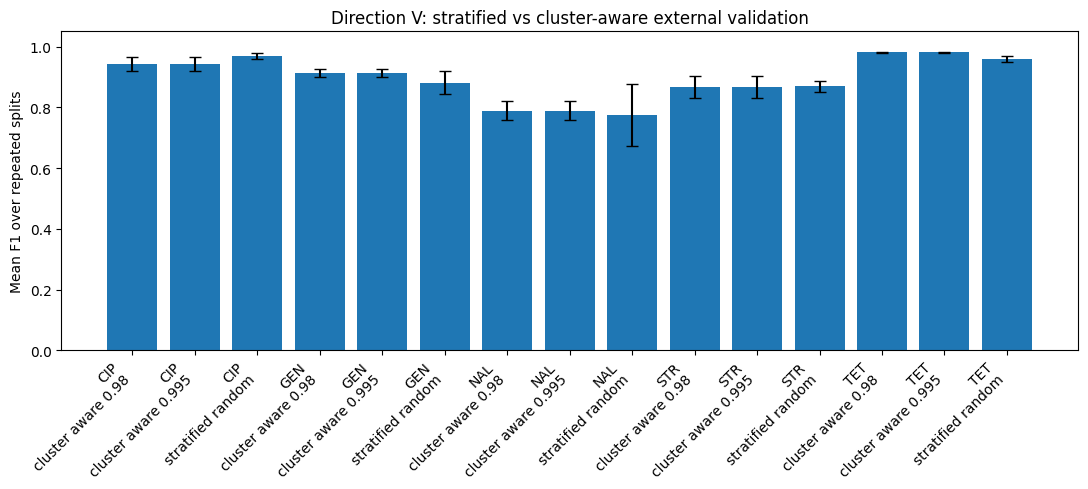

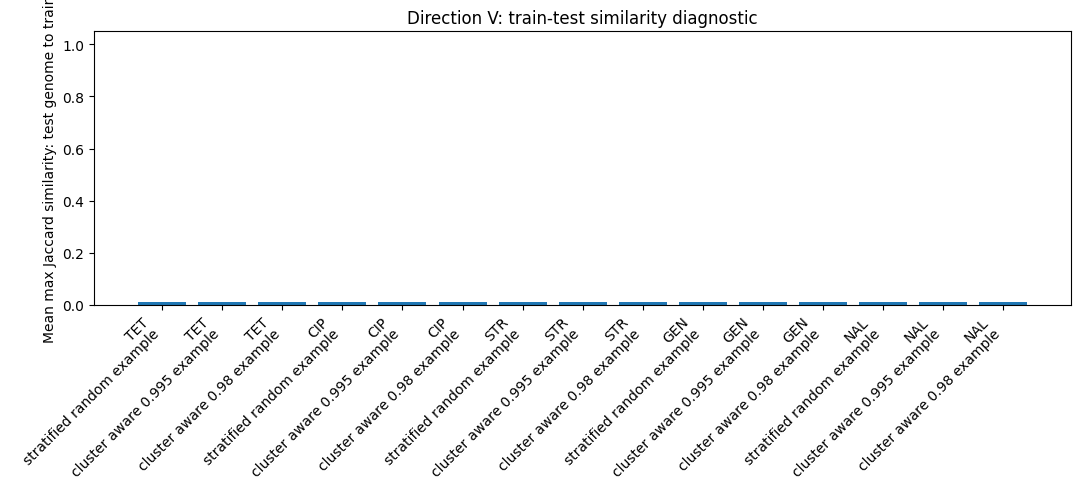

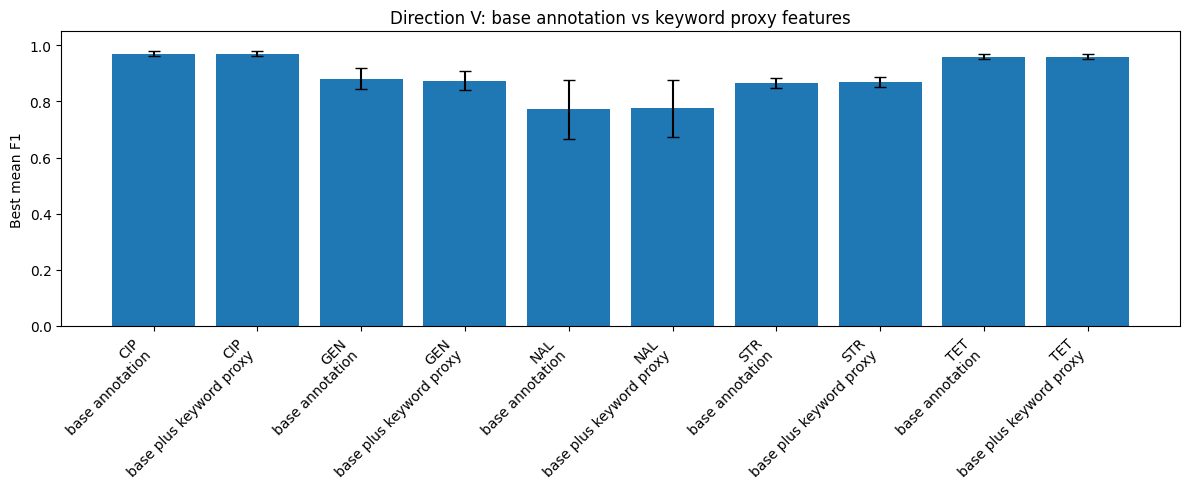

In [12]:
# =========================
# 11. Plots
# =========================

# Plot 1: best F1 per drug/split.
plot_df = best_summary.copy()
plot_df['label'] = plot_df['drug_code'] + '\n' + plot_df['split_mode'].astype(str).str.replace('_', ' ')
plt.figure(figsize=(11, 5))
plt.bar(plot_df['label'], plot_df['f1_mean'], yerr=plot_df['f1_std'].fillna(0), capsize=4)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean F1 over repeated splits')
plt.title('Direction V: stratified vs cluster-aware external validation')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'direction_V_best_f1_by_drug_split.png', dpi=200)
plt.show()

# Plot 2: similarity leakage diagnostic.
if not similarity_split_summary.empty:
    splot = similarity_split_summary.copy()
    splot['label'] = splot['drug_code'] + '\n' + splot['split_mode'].astype(str).str.replace('_', ' ')
    plt.figure(figsize=(11, 5))
    plt.bar(splot['label'], splot['mean_test_to_train_max_sim'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Mean max Jaccard similarity: test genome to train')
    plt.title('Direction V: train-test similarity diagnostic')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'direction_V_train_test_similarity_diagnostic.png', dpi=200)
    plt.show()

# Plot 3: feature set comparison on stratified_random.
fs_plot = summary[summary['split_mode'] == 'stratified_random'].copy()
if not fs_plot.empty:
    best_fs = (
        fs_plot.sort_values(['drug_code', 'feature_set', 'f1_mean'], ascending=[True, True, False])
        .groupby(['drug_code', 'feature_set'], as_index=False)
        .head(1)
    )
    best_fs['label'] = best_fs['drug_code'] + '\n' + best_fs['feature_set'].astype(str).str.replace('_', ' ')
    plt.figure(figsize=(12, 5))
    plt.bar(best_fs['label'], best_fs['f1_mean'], yerr=best_fs['f1_std'].fillna(0), capsize=4)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Best mean F1')
    plt.title('Direction V: base annotation vs keyword proxy features')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'direction_V_feature_set_comparison.png', dpi=200)
    plt.show()


## 10. Auto conclusion

Cell cuối tạo kết luận tự động cho báo cáo và zip toàn bộ outputs.


In [13]:
# =========================
# 12. Auto conclusion + zip
# =========================

lines = []
lines.append('# Direction V — Robust external validation + cluster-aware + quinolone-aware extension')
lines.append('')
lines.append('## Mục tiêu')
lines.append('Direction V phát triển từ Direction U bằng cách kiểm tra độ chắc của external validation qua cluster-aware split dựa trên Jaccard similarity, đồng thời thêm keyword/proxy AMR features cho các thuốc quinolone/fluoroquinolone như CIP/NAL.')
lines.append('')

lines.append('## Dữ liệu')
if not dataset_summary.empty:
    for _, r in dataset_summary.iterrows():
        lines.append(f"- {r['drug_code']}: usable rows={int(r['n_rows'])}, S={int(r['n_S'])}, R={int(r['n_R'])}, base features={int(r['n_base_features'])}.")
else:
    lines.append('- Chưa có dataset summary.')
lines.append('')

lines.append('## Best settings')
for _, r in best_summary.iterrows():
    f1_std = 0 if pd.isna(r.get('f1_std', np.nan)) else r['f1_std']
    auprc_std = 0 if pd.isna(r.get('auprc_std', np.nan)) else r['auprc_std']
    lines.append(
        f"- {r['drug_code']} | {r['split_mode']} | {r['feature_set']}: "
        f"best={r['model']} k={int(r['k_features'])}; "
        f"F1={r['f1_mean']:.3f}±{f1_std:.3f}, "
        f"balanced accuracy={r['bal_acc_mean']:.3f}, "
        f"AUPRC={r['auprc_mean']:.3f}±{auprc_std:.3f}."
    )
lines.append('')

lines.append('## Cluster-aware diagnostic')
if not cluster_summary.empty:
    for _, r in cluster_summary.iterrows():
        lines.append(
            f"- {r['drug_code']} threshold={r['threshold']}: n_clusters={int(r['n_clusters'])}, "
            f"largest_cluster={int(r['largest_cluster_size'])}, near_duplicate_pairs={int(r['near_duplicate_pairs_at_threshold'])}."
        )
else:
    lines.append('- Không chạy cluster-aware hoặc không tạo được cluster summary.')
lines.append('')

lines.append('## Train-test similarity diagnostic')
if not similarity_split_summary.empty:
    for _, r in similarity_split_summary.iterrows():
        lines.append(
            f"- {r['drug_code']} | {r['split_mode']}: mean max test-to-train Jaccard similarity={r['mean_test_to_train_max_sim']:.3f}, max={r['max_test_to_train_sim']:.3f}."
        )
else:
    lines.append('- Không có similarity split summary.')
lines.append('')

lines.append('## Top feature interpretation')
if not feature_summary_all.empty:
    for drug_code in sorted(feature_summary_all['drug_code'].unique()):
        sub = feature_summary_all[
            (feature_summary_all['drug_code'] == drug_code) &
            (feature_summary_all['split_mode'] == 'stratified_random')
        ]
        if sub.empty:
            sub = feature_summary_all[feature_summary_all['drug_code'] == drug_code]
        n_direct = int((sub['keyword_label'] == 'drug_mechanism_keyword').sum())
        n_general = int((sub['keyword_label'] == 'general_amr_or_mobile_keyword').sum())
        n_proxy = int((sub['keyword_label'] == 'proxy_keyword_feature').sum())
        examples = sub[sub['keyword_label'] != 'unknown_by_keyword']['feature'].head(5).tolist()
        lines.append(f'- {drug_code}: direct={n_direct}, general/mobile={n_general}, proxy={n_proxy}. Examples: {examples}')
else:
    lines.append('- Chưa có top feature annotated summary.')
lines.append('')

lines.append('## Negative control')
if not neg_all.empty:
    neg_simple = neg_all.groupby('drug_code').agg(f1_mean=('f1', 'mean'), bal_acc_mean=('balanced_accuracy', 'mean')).reset_index()
    for _, r in neg_simple.iterrows():
        lines.append(f"- {r['drug_code']}: shuffled-label F1={r['f1_mean']:.3f}, balanced accuracy={r['bal_acc_mean']:.3f}.")
else:
    lines.append('- Chưa chạy negative control.')
lines.append('')

lines.append('## Cách viết vào báo cáo')
lines.append('- Nếu cluster-aware F1 vẫn cao và train-test similarity giảm, có thể nói external validation robust hơn random split.')
lines.append('- Nếu cluster-aware giảm mạnh so với stratified random, cần viết thận trọng: hiệu năng Direction U có thể một phần đến từ genome similarity/leakage.')
lines.append('- Nếu CIP/NAL cải thiện khi thêm keyword/proxy hoặc AMRFinderPlus features, dùng làm bằng chứng rằng quinolone cần mutation/AMR-aware features riêng.')
lines.append('- Nếu CIP/NAL vẫn khó giải thích, kết luận hợp lý là cần mutation calling thật từ gyrA/parC/parE hoặc AMRFinderPlus/CARD thay vì chỉ presence/absence annotation.')

conclusion = '\n'.join(lines)
print(conclusion)

with open(OUTPUT_DIR / 'AUTO_CONCLUSION_DIRECTION_V.md', 'w', encoding='utf-8') as f:
    f.write(conclusion)

zip_path = BASE_DIR / 'salmonella_direction_V_outputs.zip'
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace('.zip', ''), 'zip', OUTPUT_DIR)

print('\nOutput dir:', OUTPUT_DIR)
print('Zip:', zip_path)

# Nếu chạy trên Colab và muốn tải zip:
# from google.colab import files
# files.download(str(zip_path))


# Direction V — Robust external validation + cluster-aware + quinolone-aware extension

## Mục tiêu
Direction V phát triển từ Direction U bằng cách kiểm tra độ chắc của external validation qua cluster-aware split dựa trên Jaccard similarity, đồng thời thêm keyword/proxy AMR features cho các thuốc quinolone/fluoroquinolone như CIP/NAL.

## Dữ liệu
- TET: usable rows=476, S=236, R=240, base features=61695.
- CIP: usable rows=483, S=239, R=244, base features=56081.
- STR: usable rows=476, S=234, R=242, base features=61174.
- GEN: usable rows=468, S=240, R=228, base features=59107.
- NAL: usable rows=479, S=242, R=237, base features=64215.

## Best settings
- CIP | cluster_aware_0.98 | base_annotation: best=lr_balanced k=500; F1=0.942±0.024, balanced accuracy=0.936, AUPRC=0.967±0.026.
- CIP | cluster_aware_0.995 | base_annotation: best=lr_balanced k=500; F1=0.942±0.024, balanced accuracy=0.936, AUPRC=0.967±0.026.
- CIP | stratified_random | base_annotation: best=lr_balanced k=500; F1=0.970